In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# core libs
!pip install -U ultralytics kaggle roboflow opencv-python matplotlib tqdm

# if you plan to do fine-grained classification later:
!pip install timm torchvision


In [ ]:
!mkdir -p /content/aod4
!unzip "/content/drive/MyDrive/archive .zip" -d /content/aod4
!ls -R /content/aod4 | head -40


Streaming output truncated to the last 5000 lines.
  inflating: /content/aod4/AOD_4_final/AOD_4/labels/train/yt-ywf2fmnNIgw-0025_jpg.rf.ac8f422839e71c7e036d48c4956faf6e.txt  
  inflating: /content/aod4/AOD_4_final/AOD_4/labels/train/yt-ywf2fmnNIgw-0027_jpg.rf.3972d41ae1343ad25fd247206f034b76.txt  
  inflating: /content/aod4/AOD_4_final/AOD_4/labels/train/yt-ywf2fmnNIgw-0029_jpg.rf.35ff4653c838f0bb29d9ee64964d4cae.txt  
  inflating: /content/aod4/AOD_4_final/AOD_4/labels/train/yt-ywf2fmnNIgw-0030_jpg.rf.ad0863801416f6351e7240c1ab2ec260.txt  
  inflating: /content/aod4/AOD_4_final/AOD_4/labels/train/yt-ywf2fmnNIgw-0031_jpg.rf.5d9e00906f6f2fb48744772521fb3e02.txt  
  inflating: /content/aod4/AOD_4_final/AOD_4/labels/train/yt-ywf2fmnNIgw-0032_jpg.rf.9b0e3b2ba5e6b24663b9360169c01df1.txt  
  inflating: /content/aod4/AOD_4_final/AOD_4/labels/train/yt-ywf2fmnNIgw-0033_jpg.rf.5c4d8cf392a0ad2c11c166bc9d56cf86.txt  
  inflating: /content/aod4/AOD_4_final/AOD_4/labels/train/yt-ywf2fmnNIgw-0034_jpg

In [ ]:
data_yaml = """
path: /content/aod4
train: images/train
val: images/val
nc: 4
names: ['airplane','bird','drone','helicopter']
"""
with open("/content/aod4/data.yaml", "w") as f:
    f.write(data_yaml)


In [ ]:
!ls -R /content/aod4 | head -40



/content/aod4:
AOD_4_final
data.yaml

/content/aod4/AOD_4_final:
AOD_4

/content/aod4/AOD_4_final/AOD_4:
data.yaml
images
labels

/content/aod4/AOD_4_final/AOD_4/images:
test
train
val

/content/aod4/AOD_4_final/AOD_4/images/test:
20190925_101846_1_1_000_jpg.rf.497f3eb572bec39e6856f75fc88b3d1b.jpg
20190925_101846_1_1_004_jpg.rf.0c12b3a3cad8a8cac2e429c602904551.jpg
20190925_101846_1_1_012_jpg.rf.650837209d9799f117a6a9f17fd5aac4.jpg
20190925_101846_1_1_024_jpg.rf.7c0b22dcf973590c4c1e33353e73d1f7.jpg
20190925_101846_1_1_052_jpg.rf.0ddc07320dab89c9869d093fd6e5474c.jpg
20190925_101846_1_1_072_jpg.rf.01279762d519866af81c76ed692406c4.jpg
20190925_101846_1_1_124_jpg.rf.7627cbeb488970ac2a32f5ea4803f52f.jpg
20190925_101846_1_1_144_jpg.rf.08c4429dc8ee95499faf57a645f2758a.jpg
20190925_101846_1_1_148_jpg.rf.8751ef5f0770dc016c5997e31a05a93c.jpg
20190925_101846_1_1_156_jpg.rf.83685a1f1e614d236256da3878dfe9bc.jpg
20190925_101846_1_1_168_jpg.rf.0cde8eb9c808ebf2a0b7abf604d1e5c4.jpg
20190925_101846_1_1_3

In [ ]:
data_yaml = """
path: /content/aod4
train: train/images
val: valid/images
nc: 4
names: ['airplane','bird','drone','helicopter']
"""
with open("/content/aod4/data.yaml", "w") as f:
    f.write(data_yaml)


In [ ]:
!ls /content/aod4 -R

Streaming output truncated to the last 5000 lines.
yt-ywf2fmnNIgw-0123_jpg.rf.fb3a48f9e0f9fa837d6198730260d226.txt
yt-ywf2fmnNIgw-0125_jpg.rf.c5e952197de39fe4ae5db24cdd9f3b9f.txt
yt-ywf2fmnNIgw-0129_jpg.rf.b3fcf03bb9fdc707071951e29a6ed57c.txt
yt-ywf2fmnNIgw-0130_jpg.rf.18e936236eac21953f1a09c267c73267.txt
yt-ywf2fmnNIgw-0131_jpg.rf.416c7fb6bb8d6af55fcdb17553c2ef59.txt
yt-ywf2fmnNIgw-0132_jpg.rf.e099b5fe1ed65006a7efca894c777c45.txt
yt-ywf2fmnNIgw-0133_jpg.rf.07c2219006af5d7e21686e45a89044f3.txt
yt-ywf2fmnNIgw-0134_jpg.rf.0a4c2f7368c94bd20d7db5f07236e3b9.txt
yt-ywf2fmnNIgw-0135_jpg.rf.04fdb092902bdd1ef6313fdbf120a3fd.txt
yt-ywf2fmnNIgw-0137_jpg.rf.a402b2698789f8dda03e7d307caef831.txt
yt-ywf2fmnNIgw-0138_jpg.rf.b183860da4335f74fc568a7c6678a7be.txt
yt-ywf2fmnNIgw-0139_jpg.rf.a24b2fa2810dfaf604272a012dd5aad3.txt
yt-ywf2fmnNIgw-0141_jpg.rf.7e1f1ed68c0984b3a95e31c9698e0d40.txt
yt-ywf2fmnNIgw-0142_jpg.rf.635daf755876ef62086adb2705c7e295.txt
yt-ywf2fmnNIgw-0143_jpg.rf.dc796e80b016b30e4c1b7dc5ab

In [ ]:
from ultralytics import YOLO

# Load the best model from the previous training run
model = YOLO('/content/drive/MyDrive/aod4_best.pt')  # Load your saved best weights

# Continue training for a total of 50 epochs
model.train(
    data='/content/aod4/data.yaml',
    epochs=40,  # Set the total number of epochs you want to reach
    imgsz=640,
    batch=16,
    name='aod4_yolov8n_continued' # Give a new name to the continued training run
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/aod4_best.pt'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Copy best model to your Drive
# The model is saved in a directory named after your training run
!cp /content/runs/detect/aod4_yolov8n_continued/weights/best.pt /content/drive/MyDrive/aod4_best_continued.pt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from ultralytics import YOLO

# Load model from Google Drive
model = YOLO("/content/drive/MyDrive/aod4_best_continued.pt")

# Run prediction on an image
results = model.predict(source="/content/aod4/test/images/20190925_101846_1_1_000_jpg.rf.497f3eb572bec39e6856f75fc88b3d1b.jpg", save=True)


image 1/1 /content/aod4/test/images/20190925_101846_1_1_000_jpg.rf.497f3eb572bec39e6856f75fc88b3d1b.jpg: 640x640 1 drone, 7.7ms
Speed: 5.9ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


In [ ]:
# Evaluate model performance on validation set
metrics = model.val()

# Run prediction on a sample image
results = model.predict(source='/content/aod4/test/images/20190925_101846_1_1_000_jpg.rf.497f3eb572bec39e6856f75fc88b3d1b.jpg', save=True, conf=0.25)

Ultralytics 8.3.208 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 972.4±495.7 MB/s, size: 37.4 KB)
val: Scanning /content/aod4/valid/labels.cache... 4514 images, 125 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4514/4514 6.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 283/283 5.8it/s 48.6s
                   all       4514       6369      0.949      0.939      0.968      0.672
              airplane       1119       1625      0.962      0.933      0.971      0.709
                  bird        638       1557      0.946      0.951      0.974      0.715
                 drone       1485       1602      0.937      0.926      0.957      0.625
            helicopter       1158       1585      0.952      0.947      0.969       0.64
Speed: 0.4ms preprocess, 3.7ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val

i

In [ ]:
import os
from IPython.display import Image, display

# Replace with the actual filename of an image with bird detections from the test set
image_filename = "jasinthan-yoganathan-9exeLsj-cR8-unsplash_jpg.rf.376105bedef8000cd36d92fd1fa5916b.jpg"

# Find the latest prediction run directory
runs_dir = '/content/runs/detect/'
latest_run = sorted([d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))])[-1]
predicted_image_path = os.path.join(runs_dir, latest_run, image_filename)

# Display the image if it exists
if os.path.exists(predicted_image_path):
    display(Image(filename=predicted_image_path))
else:
    print(f"Predicted image not found at: {predicted_image_path}")

Predicted image not found at: /content/runs/detect/val/jasinthan-yoganathan-9exeLsj-cR8-unsplash_jpg.rf.376105bedef8000cd36d92fd1fa5916b.jpg


In [ ]:
import os
from IPython.display import Image, display
from ultralytics import YOLO

# Load model from Google Drive
model = YOLO("/content/drive/MyDrive/aod4_best_continued.pt")

# Path to the test images directory
test_images_dir = '/content/aod4/test/images/'

# Get list of all image files in the test directory
image_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Iterate through each image file
for image_file in image_files:
    image_path = os.path.join(test_images_dir, image_file)

    # Run prediction on the current image
    results = model.predict(source=image_path, save=True, conf=0.25)

    # Check if any detections are found and if the detected classes include 'airplane' or 'bird'
    if results and len(results[0].boxes) > 0:
        detected_classes = [model.names[int(box.cls)] for box in results[0].boxes]
        if 'airplane' in detected_classes or 'bird' in detected_classes:
            print(f"Detected airplane or bird in: {image_file}")
            # Display the image with predictions
            # The output directory changes based on the run, so we find the latest run directory
            runs_dir = '/content/runs/detect/'
            latest_run = sorted([d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))])[-1]
            # Construct the predicted image path based on the observed output structure
            predicted_image_path = os.path.join(runs_dir, latest_run, image_file)
            if os.path.exists(predicted_image_path):
                display(Image(filename=predicted_image_path))
            else:
                print(f"Predicted image not found at: {predicted_image_path}")

Streaming output truncated to the last 5000 lines.

image 1/1 /content/aod4/test/images/yt-vpQEQ81cfoA-0096_jpg.rf.8073f14a68a8a69aed425e1c94bebfbf.jpg: 640x640 1 airplane, 8.3ms
Speed: 4.5ms preprocess, 8.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict3
Detected airplane or bird in: yt-vpQEQ81cfoA-0096_jpg.rf.8073f14a68a8a69aed425e1c94bebfbf.jpg
Predicted image not found at: /content/runs/detect/val/yt-vpQEQ81cfoA-0096_jpg.rf.8073f14a68a8a69aed425e1c94bebfbf.jpg

image 1/1 /content/aod4/test/images/yt-9XNkOEdAvbo-0153_jpg.rf.0d3c1f13f26488a99ce123a29c624505.jpg: 640x640 1 airplane, 8.8ms
Speed: 4.6ms preprocess, 8.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict3
Detected airplane or bird in: yt-9XNkOEdAvbo-0153_jpg.rf.0d3c1f13f26488a99ce123a29c624505.jpg
Predicted image not found at: /content/runs/detect/val/yt-9XNkOEdAvbo-0153_jpg.rf.0d3c1f13f26488a99c

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# Load the best model
model = YOLO("/content/drive/MyDrive/aod4_best_continued.pt")

# Path to the image you want to predict on
image_to_predict = "/content/aod4/test/images/yt-0BFf4YWpzHM-0181_jpg.rf.2b0945721cc7d77fe8012ba02ab523d4.jpg" # Replace with your image path

# Run prediction
results = model.predict(source=image_to_predict, save=True, conf=0.25)

# Check if any detections are found and if the detected classes include 'airplane' or 'bird'
if results and len(results[0].boxes) > 0:
    detected_classes = [model.names[int(box.cls)] for box in results[0].boxes]
    if 'airplane' in detected_classes or 'bird' in detected_classes:
        print(f"Detected airplane or bird in: {image_to_predict}")
        # Display the image with predictions
        # The output directory changes based on the run, so we find the latest run directory
        runs_dir = '/content/runs/detect/'
        latest_run = sorted([d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))])[-1]
        # Extract just the filename from the image_to_predict path
        image_filename = os.path.basename(image_to_predict)
        predicted_image_path = os.path.join(runs_dir, latest_run, image_filename)
        if os.path.exists(predicted_image_path):
            display(Image(filename=predicted_image_path))
        else:
            print(f"Predicted image not found at: {predicted_image_path}")


image 1/1 /content/aod4/test/images/yt-0BFf4YWpzHM-0181_jpg.rf.2b0945721cc7d77fe8012ba02ab523d4.jpg: 640x640 1 airplane, 7.2ms
Speed: 2.9ms preprocess, 7.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict4
Detected airplane or bird in: /content/aod4/test/images/yt-0BFf4YWpzHM-0181_jpg.rf.2b0945721cc7d77fe8012ba02ab523d4.jpg
Predicted image not found at: /content/runs/detect/val/yt-0BFf4YWpzHM-0181_jpg.rf.2b0945721cc7d77fe8012ba02ab523d4.jpg


In [ ]:
import os
from IPython.display import Image, display

# Replace with the actual filename of an image with helicopter detections from the test set
image_filename = "V_HELICOPTER_051275_151_png_jpg.rf.0647c9d1cee197dced99c3cbde285ad7.jpg"

# Find the latest prediction run directory
runs_dir = '/content/runs/detect/'
# Get all entries in runs_dir that are directories
all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
# Filter out the 'val' directory if it's present
prediction_runs = [d for d in all_runs if not d.startswith('val')]
# Sort the prediction run directories and get the latest one
latest_run = sorted(prediction_runs)[-1] if prediction_runs else None

predicted_image_path = os.path.join(runs_dir, latest_run, image_filename)

# Display the image if it exists
if latest_run and os.path.exists(predicted_image_path):
    display(Image(filename=predicted_image_path))
else:
    print(f"Predicted image not found at: {predicted_image_path}")

Predicted image not found at: /content/runs/detect/predict7/V_HELICOPTER_051275_151_png_jpg.rf.0647c9d1cee197dced99c3cbde285ad7.jpg


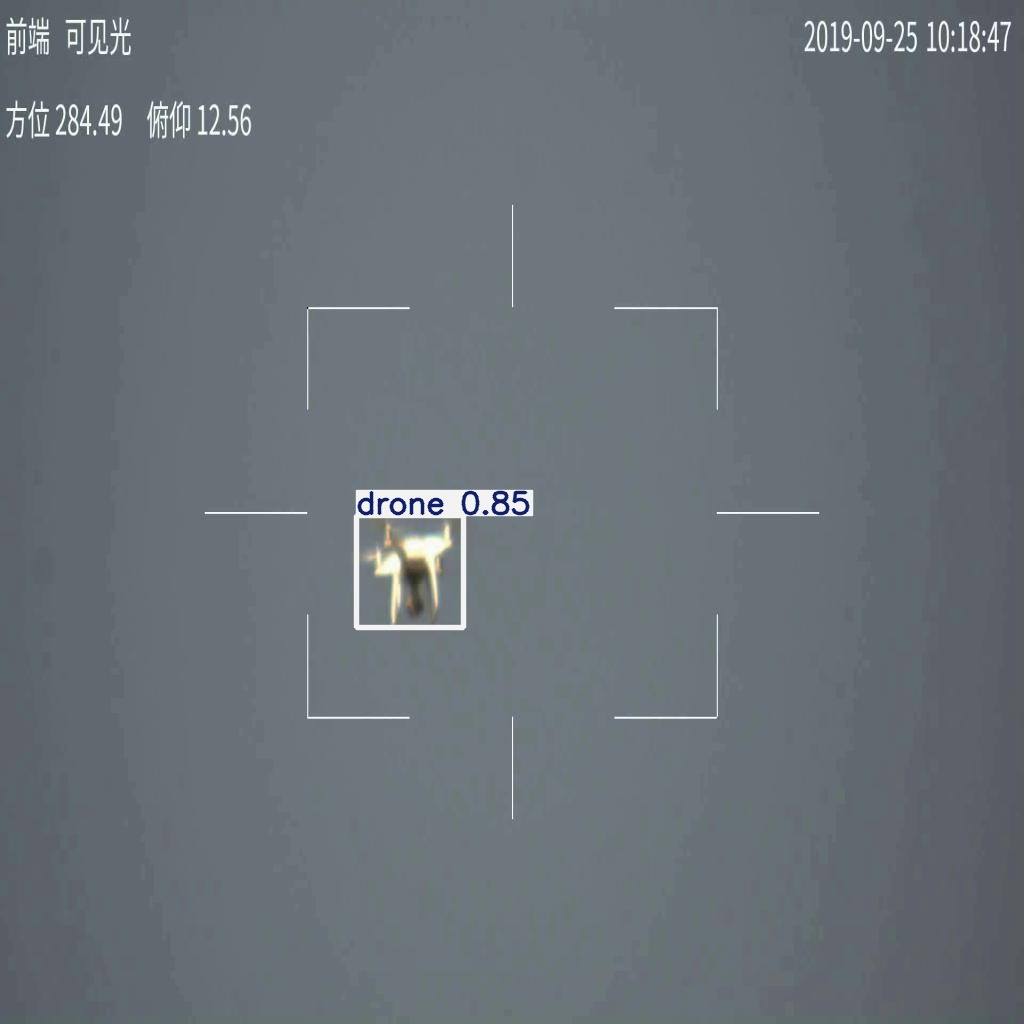

In [ ]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict/20190925_101846_1_1_000_jpg.rf.497f3eb572bec39e6856f75fc88b3d1b.jpg")


image 1/1 /content/aod4/test/images/V_DRONE_047157_041_png_jpg.rf.e5965ebd4d8bd736c28328019350646e.jpg: 640x640 1 drone, 7.7ms
Speed: 4.4ms preprocess, 7.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict8
--- Prediction Results ---
Detected classes: ['drone']
A drone was detected in the image during this prediction run.
Predicted image found at: /content/runs/detect/predict8/V_DRONE_047157_041_png_jpg.rf.e5965ebd4d8bd736c28328019350646e.jpg

Displaying the predicted image:


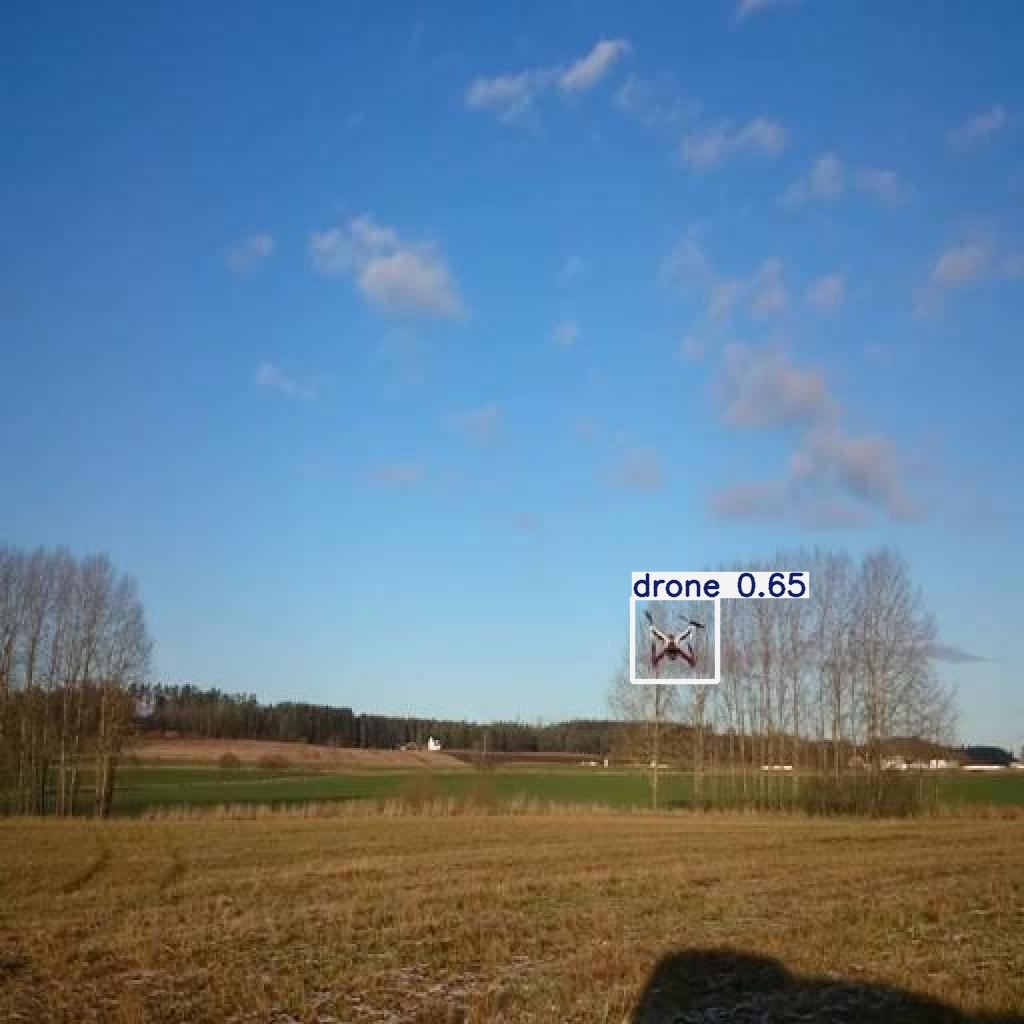

--- End of Prediction Results ---


In [ ]:
import os
from IPython.display import Image, display
from ultralytics import YOLO

# Load the best model
model = YOLO("/content/drive/MyDrive/aod4_best.pt")

# Path to the image you want to predict on
image_to_predict = "/content/aod4/test/images/V_DRONE_047157_041_png_jpg.rf.e5965ebd4d8bd736c28328019350646e.jpg"

# Run prediction on the image and save the results
# save=True will save the predicted image with bounding boxes
results = model.predict(source=image_to_predict, save=True, conf=0.25)

# Find the latest prediction run directory
runs_dir = '/content/runs/detect/'
all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
prediction_runs = sorted([d for d in all_runs if d.startswith('predict')],
                         key=lambda x: int(x.replace('predict', '')) if x.replace('predict', '').isdigit() else 0)

# Corrected indexing to get the directory name from the tuple
latest_run = prediction_runs[-1] if prediction_runs else None
if latest_run and isinstance(latest_run, tuple): # Ensure it's a tuple before accessing the second element
    latest_run = latest_run[1]
elif latest_run and isinstance(latest_run, str):
    # If it's already a string (from a previous predict run not sorted numerically), use it directly
    pass


# Construct the expected path to the predicted image
predicted_image_filename = os.path.basename(image_to_predict)
predicted_image_path = os.path.join(runs_dir, latest_run, predicted_image_filename) if latest_run else None


print(f"--- Prediction Results ---")
if results and len(results[0].boxes) > 0:
    detected_classes = [model.names[int(box.cls)] for box in results[0].boxes]
    print(f"Detected classes: {detected_classes}")

    if 'drone' in detected_classes:
        print("A drone was detected in the image during this prediction run.")

        # Check if the predicted image file was saved
        if predicted_image_path and os.path.exists(predicted_image_path):
            print(f"Predicted image found at: {predicted_image_path}")
            print("\nDisplaying the predicted image:")
            display(Image(filename=predicted_image_path))
        elif predicted_image_path:
             print(f"Predicted image file not found at the expected path: {predicted_image_path}")
             print("Listing files in the latest prediction directory:")
             if latest_run and os.path.exists(os.path.join(runs_dir, latest_run)): # Added check for directory existence
                 print(os.listdir(os.path.join(runs_dir, latest_run)))
             else:
                 print("Could not determine or access the latest prediction directory.")
        else:
             print("Could not determine the expected path for the predicted image.")

    else:
        print("No drone was detected in the image during this prediction run.")
        if predicted_image_path and os.path.exists(predicted_image_path):
             print(f"Predicted image was still saved at: {predicted_image_path}")
             print("\nDisplaying the predicted image:")
             display(Image(filename=predicted_image_path))


elif results:
    print("No objects were detected in the image during this prediction run.")
    if predicted_image_path and os.path.exists(predicted_image_path):
        print(f"Predicted image was still saved at: {predicted_image_path}")
        print("\nDisplaying the predicted image:")
        display(Image(filename=predicted_image_path))

else:
    print("Prediction did not return any results.")

print(f"--- End of Prediction Results ---")


image 1/1 /content/aod4/test/images/yt-0BFf4YWpzHM-0181_jpg.rf.2b0945721cc7d77fe8012ba02ab523d4.jpg: 640x640 1 airplane, 7.4ms
Speed: 3.7ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict10
Checking directory: /content/runs/detect/
All entries in /content/runs/detect/: ['val2', 'predict', 'predict7', 'val', 'predict6', 'predict5', 'predict9', 'predict2', 'predict4', 'predict8', 'predict10', 'aod4_yolov8n_continued', 'predict3']
Latest prediction run directory identified: predict10
Attempting to find predicted image at: /content/runs/detect/predict10/yt-0BFf4YWpzHM-0181_jpg.rf.2b0945721cc7d77fe8012ba02ab523d4.jpg
Predicted image found.


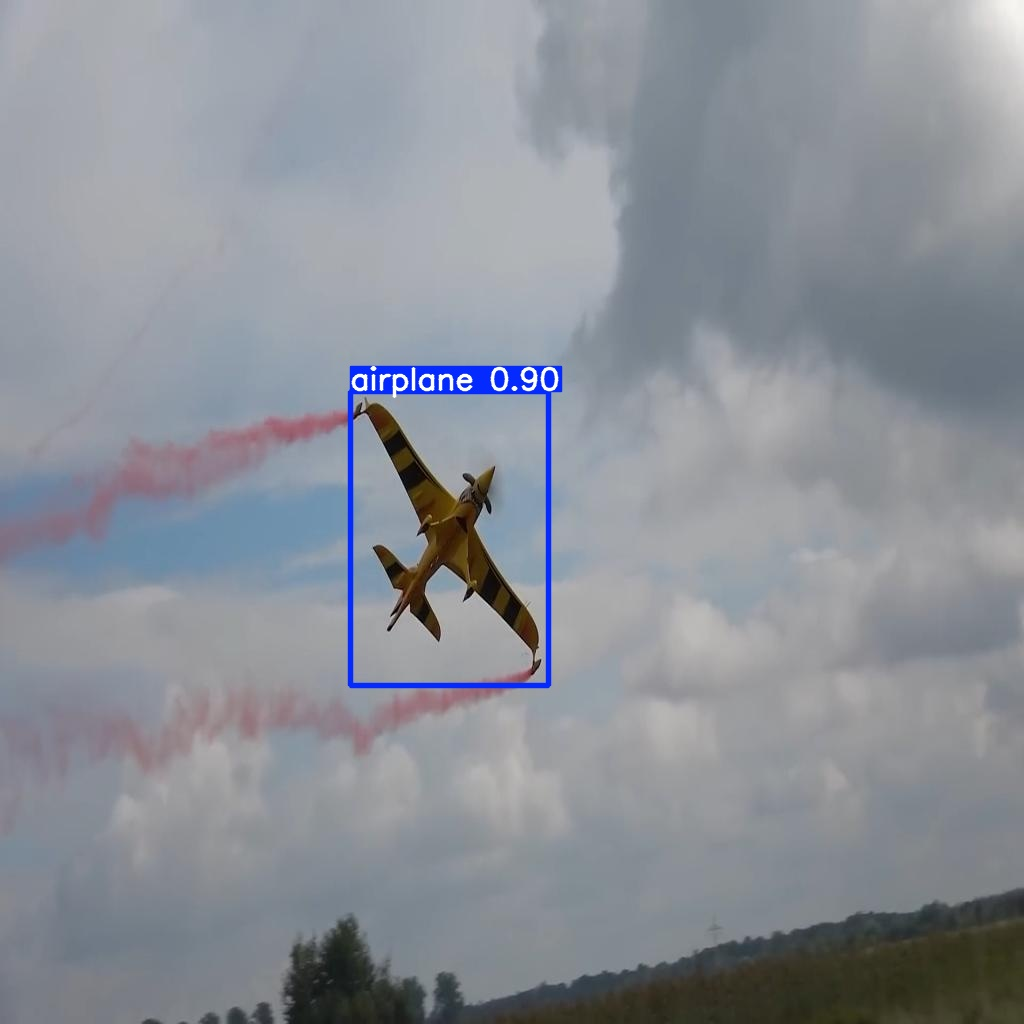

In [ ]:
import os
from IPython.display import Image, display
from ultralytics import YOLO

# Load the best model
model = YOLO("/content/drive/MyDrive/aod4_best_continued.pt")

# Replace with the actual filename of an image with airplane or bird detections
# You can find the filenames in the output of the previous cell that iterated through the test set
image_to_predict_path = "/content/aod4/test/images/yt-0BFf4YWpzHM-0181_jpg.rf.2b0945721cc7d77fe8012ba02ab523d4.jpg"

# Run prediction on the image and save the results
# save=True will save the predicted image with bounding boxes
results = model.predict(source=image_to_predict_path, save=True, conf=0.25)

# Find the latest prediction run directory
runs_dir = '/content/runs/detect/'
print(f"Checking directory: {runs_dir}")
if not os.path.exists(runs_dir):
    print(f"Error: The directory {runs_dir} does not exist.")
else:
    all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
    print(f"All entries in {runs_dir}: {all_runs}")

    # Filter out directories that don't start with 'predict' and sort them numerically
    prediction_runs = []
    for d in all_runs:
        if d.startswith('predict'):
            try:
                run_number = int(d.replace('predict', ''))
                prediction_runs.append((run_number, d))
            except ValueError:
                # Ignore directories that don't have a valid number after 'predict'
                pass

    # Get the directory name of the latest prediction run
    latest_run_info = sorted(prediction_runs)[-1] if prediction_runs else None
    latest_run = latest_run_info[1] if latest_run_info else None

    print(f"Latest prediction run directory identified: {latest_run}")

    # Construct the predicted image path and display the image if it exists
    if latest_run:
        image_filename = os.path.basename(image_to_predict_path)
        predicted_image_path = os.path.join(runs_dir, latest_run, image_filename)
        print(f"Attempting to find predicted image at: {predicted_image_path}")

        if os.path.exists(predicted_image_path):
            print(f"Predicted image found.")
            display(Image(filename=predicted_image_path))
        else:
            print(f"Predicted image not found at: {predicted_image_path}")
            print(f"Contents of {os.path.join(runs_dir, latest_run)}:")
            if os.path.exists(os.path.join(runs_dir, latest_run)):
                 print(os.listdir(os.path.join(runs_dir, latest_run)))
            else:
                 print("Latest run directory does not exist.")

    else:
        print("No prediction run directories found starting with 'predict'.")


image 1/1 /content/aod4/test/images/pexels-david-yu-3124958_jpg.rf.70b07333506a22b063fcf285b436f28b.jpg: 640x640 2 birds, 7.2ms
Speed: 3.2ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict9
Detected bird in: /content/aod4/test/images/pexels-david-yu-3124958_jpg.rf.70b07333506a22b063fcf285b436f28b.jpg


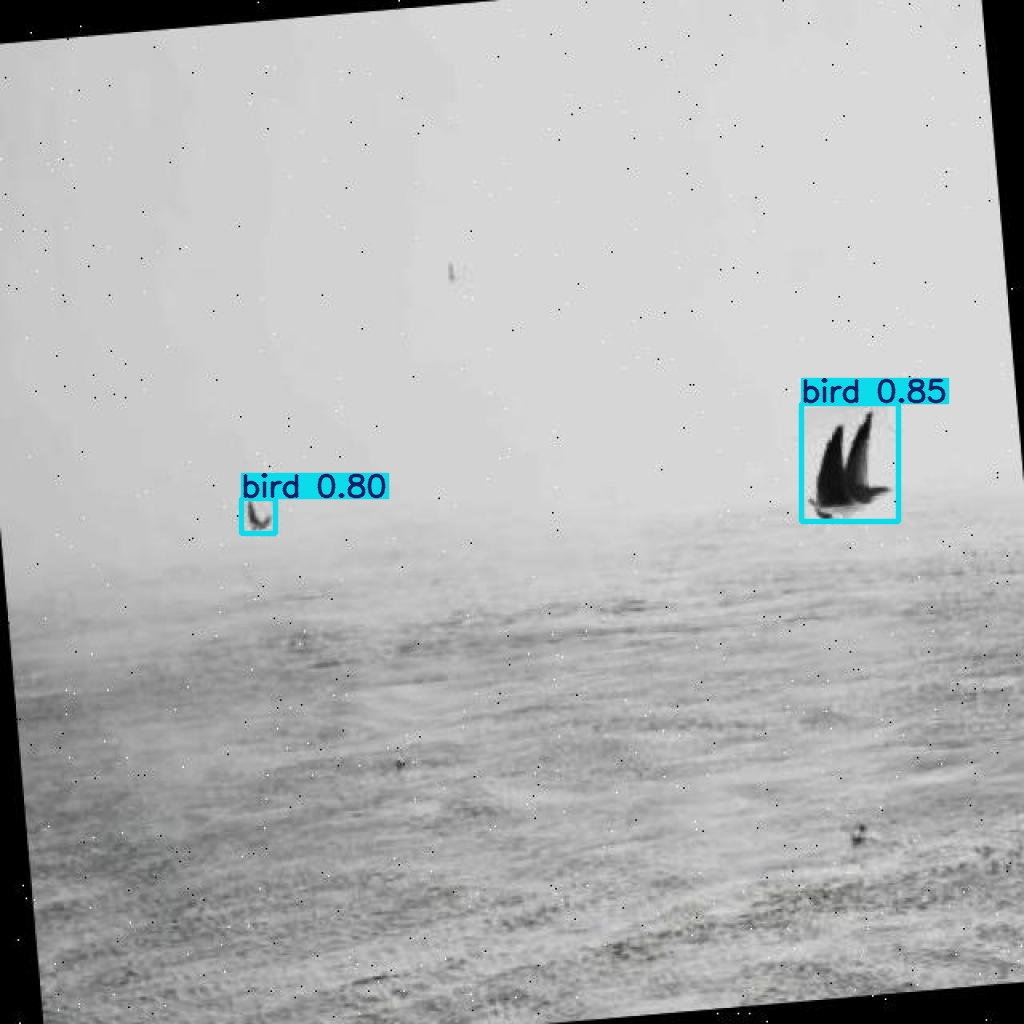

In [ ]:
import os
from IPython.display import Image, display
from ultralytics import YOLO

# Load the best model
model = YOLO("/content/drive/MyDrive/aod4_best.pt")

# Path to an image with a bird from the test set (using a different image)
image_to_predict = "/content/aod4/test/images/pexels-david-yu-3124958_jpg.rf.70b07333506a22b063fcf285b436f28b.jpg" # Another example image with birds

# Run prediction
results = model.predict(source=image_to_predict, save=True, conf=0.25)

# Check if any detections are found and if the detected classes include 'bird'
if results and len(results[0].boxes) > 0:
    detected_classes = [model.names[int(box.cls)] for box in results[0].boxes]
    if 'bird' in detected_classes:
        print(f"Detected bird in: {image_to_predict}")
        # Display the image with predictions
        # Find the latest prediction run directory, excluding 'val'
        runs_dir = '/content/runs/detect/'
        all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
        prediction_runs = [d for d in all_runs if not d.startswith('val')]
        latest_run = sorted(prediction_runs)[-1] if prediction_runs else None

        # Construct the predicted image path
        if latest_run:
            image_filename = os.path.basename(image_to_predict)
            predicted_image_path = os.path.join(runs_dir, latest_run, image_filename)
            if os.path.exists(predicted_image_path):
                display(Image(filename=predicted_image_path))
            else:
                print(f"Predicted image not found at: {predicted_image_path}")
        else:
            print("No prediction run directories found.")


image 1/1 /content/aod4/test/images/V_HELICOPTER_051275_151_png_jpg.rf.0647c9d1cee197dced99c3cbde285ad7.jpg: 640x640 1 helicopter, 7.2ms
Speed: 2.7ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict6
Detected helicopter in: /content/aod4/test/images/V_HELICOPTER_051275_151_png_jpg.rf.0647c9d1cee197dced99c3cbde285ad7.jpg
All run directories: ['predict', 'val', 'predict6', 'predict5', 'predict2', 'predict4', 'aod4_yolov8n_continued', 'predict3']
Prediction run directories (filtered and sorted): [(6, 'predict6'), (5, 'predict5'), (2, 'predict2'), (4, 'predict4'), (3, 'predict3')]
Latest prediction run directory identified: predict6


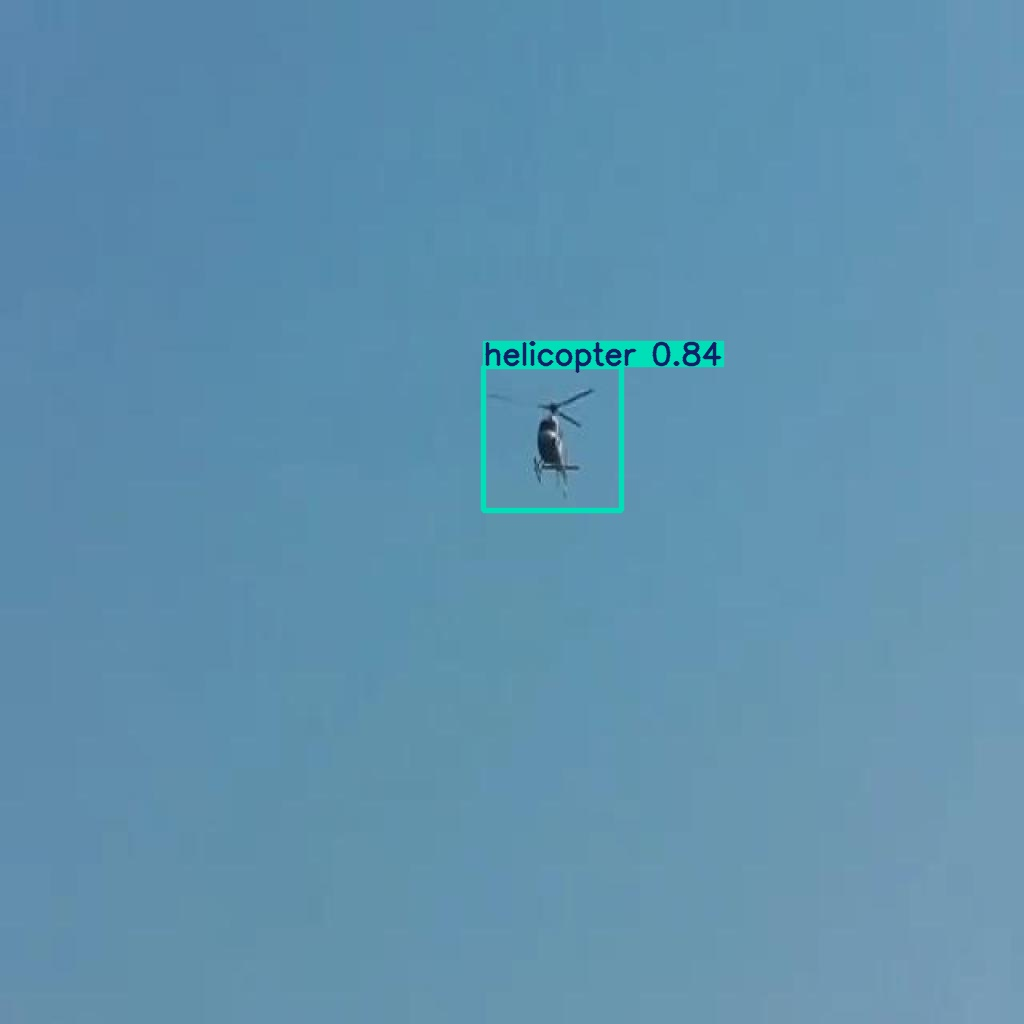

In [ ]:
import os
from IPython.display import Image, display
from ultralytics import YOLO

# Load the best model
model = YOLO("/content/drive/MyDrive/aod4_best_continued.pt")

# Path to an image with a helicopter from the test set
image_to_predict = "/content/aod4/test/images/V_HELICOPTER_051275_151_png_jpg.rf.0647c9d1cee197dced99c3cbde285ad7.jpg" # Example image with a helicopter

# Run prediction
results = model.predict(source=image_to_predict, save=True, conf=0.25)

# Check if any detections are found and if the detected classes include 'helicopter'
if results and len(results[0].boxes) > 0:
    detected_classes = [model.names[int(box.cls)] for box in results[0].boxes]
    if 'helicopter' in detected_classes:
        print(f"Detected helicopter in: {image_to_predict}")
        # Display the image with predictions
        # Find the latest prediction run directory, excluding 'val'
        runs_dir = '/content/runs/detect/'
        all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
        # Filter out directories that don't start with 'predict' and sort them numerically
        prediction_runs = []
        for d in all_runs:
            if d.startswith('predict'):
                try:
                    run_number = int(d.replace('predict', ''))
                    prediction_runs.append((run_number, d))
                except ValueError:
                    # Ignore directories that don't have a valid number after 'predict'
                    pass

        latest_run = sorted(prediction_runs)[-1][1] if prediction_runs else None

        # Debugging print statements
        print(f"All run directories: {all_runs}")
        print(f"Prediction run directories (filtered and sorted): {prediction_runs}")
        print(f"Latest prediction run directory identified: {latest_run}")


        # Construct the predicted image path
        if latest_run:
            image_filename = os.path.basename(image_to_predict)
            predicted_image_path = os.path.join(runs_dir, latest_run, image_filename)
            if os.path.exists(predicted_image_path):
                display(Image(filename=predicted_image_path))
            else:
                print(f"Predicted image not found at: {predicted_image_path}")
        else:
            print("No prediction run directories found.")

Image downloaded successfully to: /content/downloaded_image.jpg

image 1/1 /content/downloaded_image.jpg: 384x640 5 birds, 1 drone, 39.7ms
Speed: 1.6ms preprocess, 39.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict7
Prediction results saved for: /content/downloaded_image.jpg
Displaying the predicted image with detections:


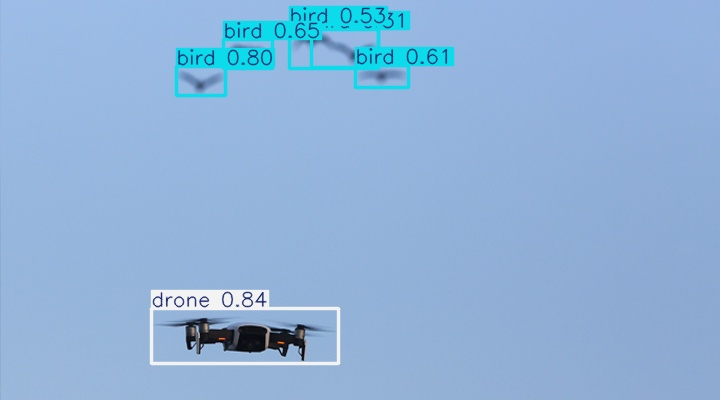

In [ ]:
import os
import requests
from IPython.display import Image, display
from ultralytics import YOLO

# Load the best model from your Google Drive
model = YOLO("/content/drive/MyDrive/aod4_best_continued.pt")

# --- Specify the URL of your new image file here ---
image_url_bird_drone = "https://gradiant.org/wp-content/uploads/2020/09/Cabecera_AdobeStock_300246618.jpg" # Replace with the actual URL of your image

# Define a path to save the downloaded image
download_path = "/content/downloaded_image.jpg" # You can change the filename if needed

# Download the image from the URL
try:
    response = requests.get(image_url_bird_drone, stream=True)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    with open(download_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Image downloaded successfully to: {download_path}")

    # Run prediction on the downloaded image
    # save=True will save the predicted image with bounding boxes
    results_bird_drone = model.predict(source=download_path, save=True, conf=0.25)

    # Optional: Display the predicted image
    if results_bird_drone and len(results_bird_drone[0].boxes) > 0:
        print(f"Prediction results saved for: {download_path}")
        # Find the latest prediction run directory
        runs_dir = '/content/runs/detect/'
        all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
        # Filter out directories that don't start with 'predict' and sort them numerically
        prediction_runs = []
        for d in all_runs:
            if d.startswith('predict'):
                try:
                    run_number = int(d.replace('predict', ''))
                    prediction_runs.append((run_number, d))
                except ValueError:
                    # Ignore directories that don't have a valid number after 'predict'
                    pass

        latest_run = sorted(prediction_runs)[-1][1] if prediction_runs else None

        if latest_run:
            image_filename_bird_drone = os.path.basename(download_path)
            predicted_image_path_bird_drone = os.path.join(runs_dir, latest_run, image_filename_bird_drone)
            if os.path.exists(predicted_image_path_bird_drone):
                print("Displaying the predicted image with detections:")
                display(Image(filename=predicted_image_path_bird_drone))
            else:
                print(f"Predicted image not found at: {predicted_image_path_bird_drone}")
        else:
            print("No prediction run directories found.")
    else:
        print(f"No objects detected in {download_path}")

except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")
except Exception as e:
    print(f"An error occurred during prediction or display: {e}")

In [ ]:
from ultralytics import YOLO

# Load the best model
model = YOLO("/content/drive/MyDrive/aod4_best_continued.pt")

# Evaluate the model on the validation set
metrics = model.val()

# Print the evaluation metrics
print("--- Model Evaluation Metrics ---")
print(f"mAP@0.5: {metrics.box.map50}")
print(f"mAP@0.5:0.95: {metrics.box.map}")
print(f"Precision: {metrics.box.p}")
print(f"Recall: {metrics.box.r}")
print("--------------------------------")

# You can access metrics for each class as well:
# print("\nMetrics per class:")
# for i, class_name in enumerate(model.names):
#     print(f"Class '{class_name}':")
#     print(f"  Precision: {metrics.box.p[i]}")
#     print(f"  Recall: {metrics.box.r[i]}")
#     print(f"  mAP@0.5: {metrics.box.map50[i]}")
#     print(f"  mAP@0.5:0.95: {metrics.box.map[i]}")

Ultralytics 8.3.208 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1297.0±740.5 MB/s, size: 48.4 KB)
val: Scanning /content/aod4/valid/labels.cache... 4514 images, 125 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4514/4514 8.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 283/283 5.6it/s 50.7s
                   all       4514       6369      0.949      0.939      0.968      0.672
              airplane       1119       1625      0.962      0.933      0.971      0.709
                  bird        638       1557      0.946      0.951      0.974      0.715
                 drone       1485       1602      0.937      0.926      0.957      0.625
            helicopter       1158       1585      0.952      0.947      0.969       0.64
Speed: 0.5ms preprocess, 4.0ms inference, 0.0

Latest validation run directory: /content/runs/detect/val2

--- Model Evaluation Visualizations ---

Displaying Confusion Matrix:


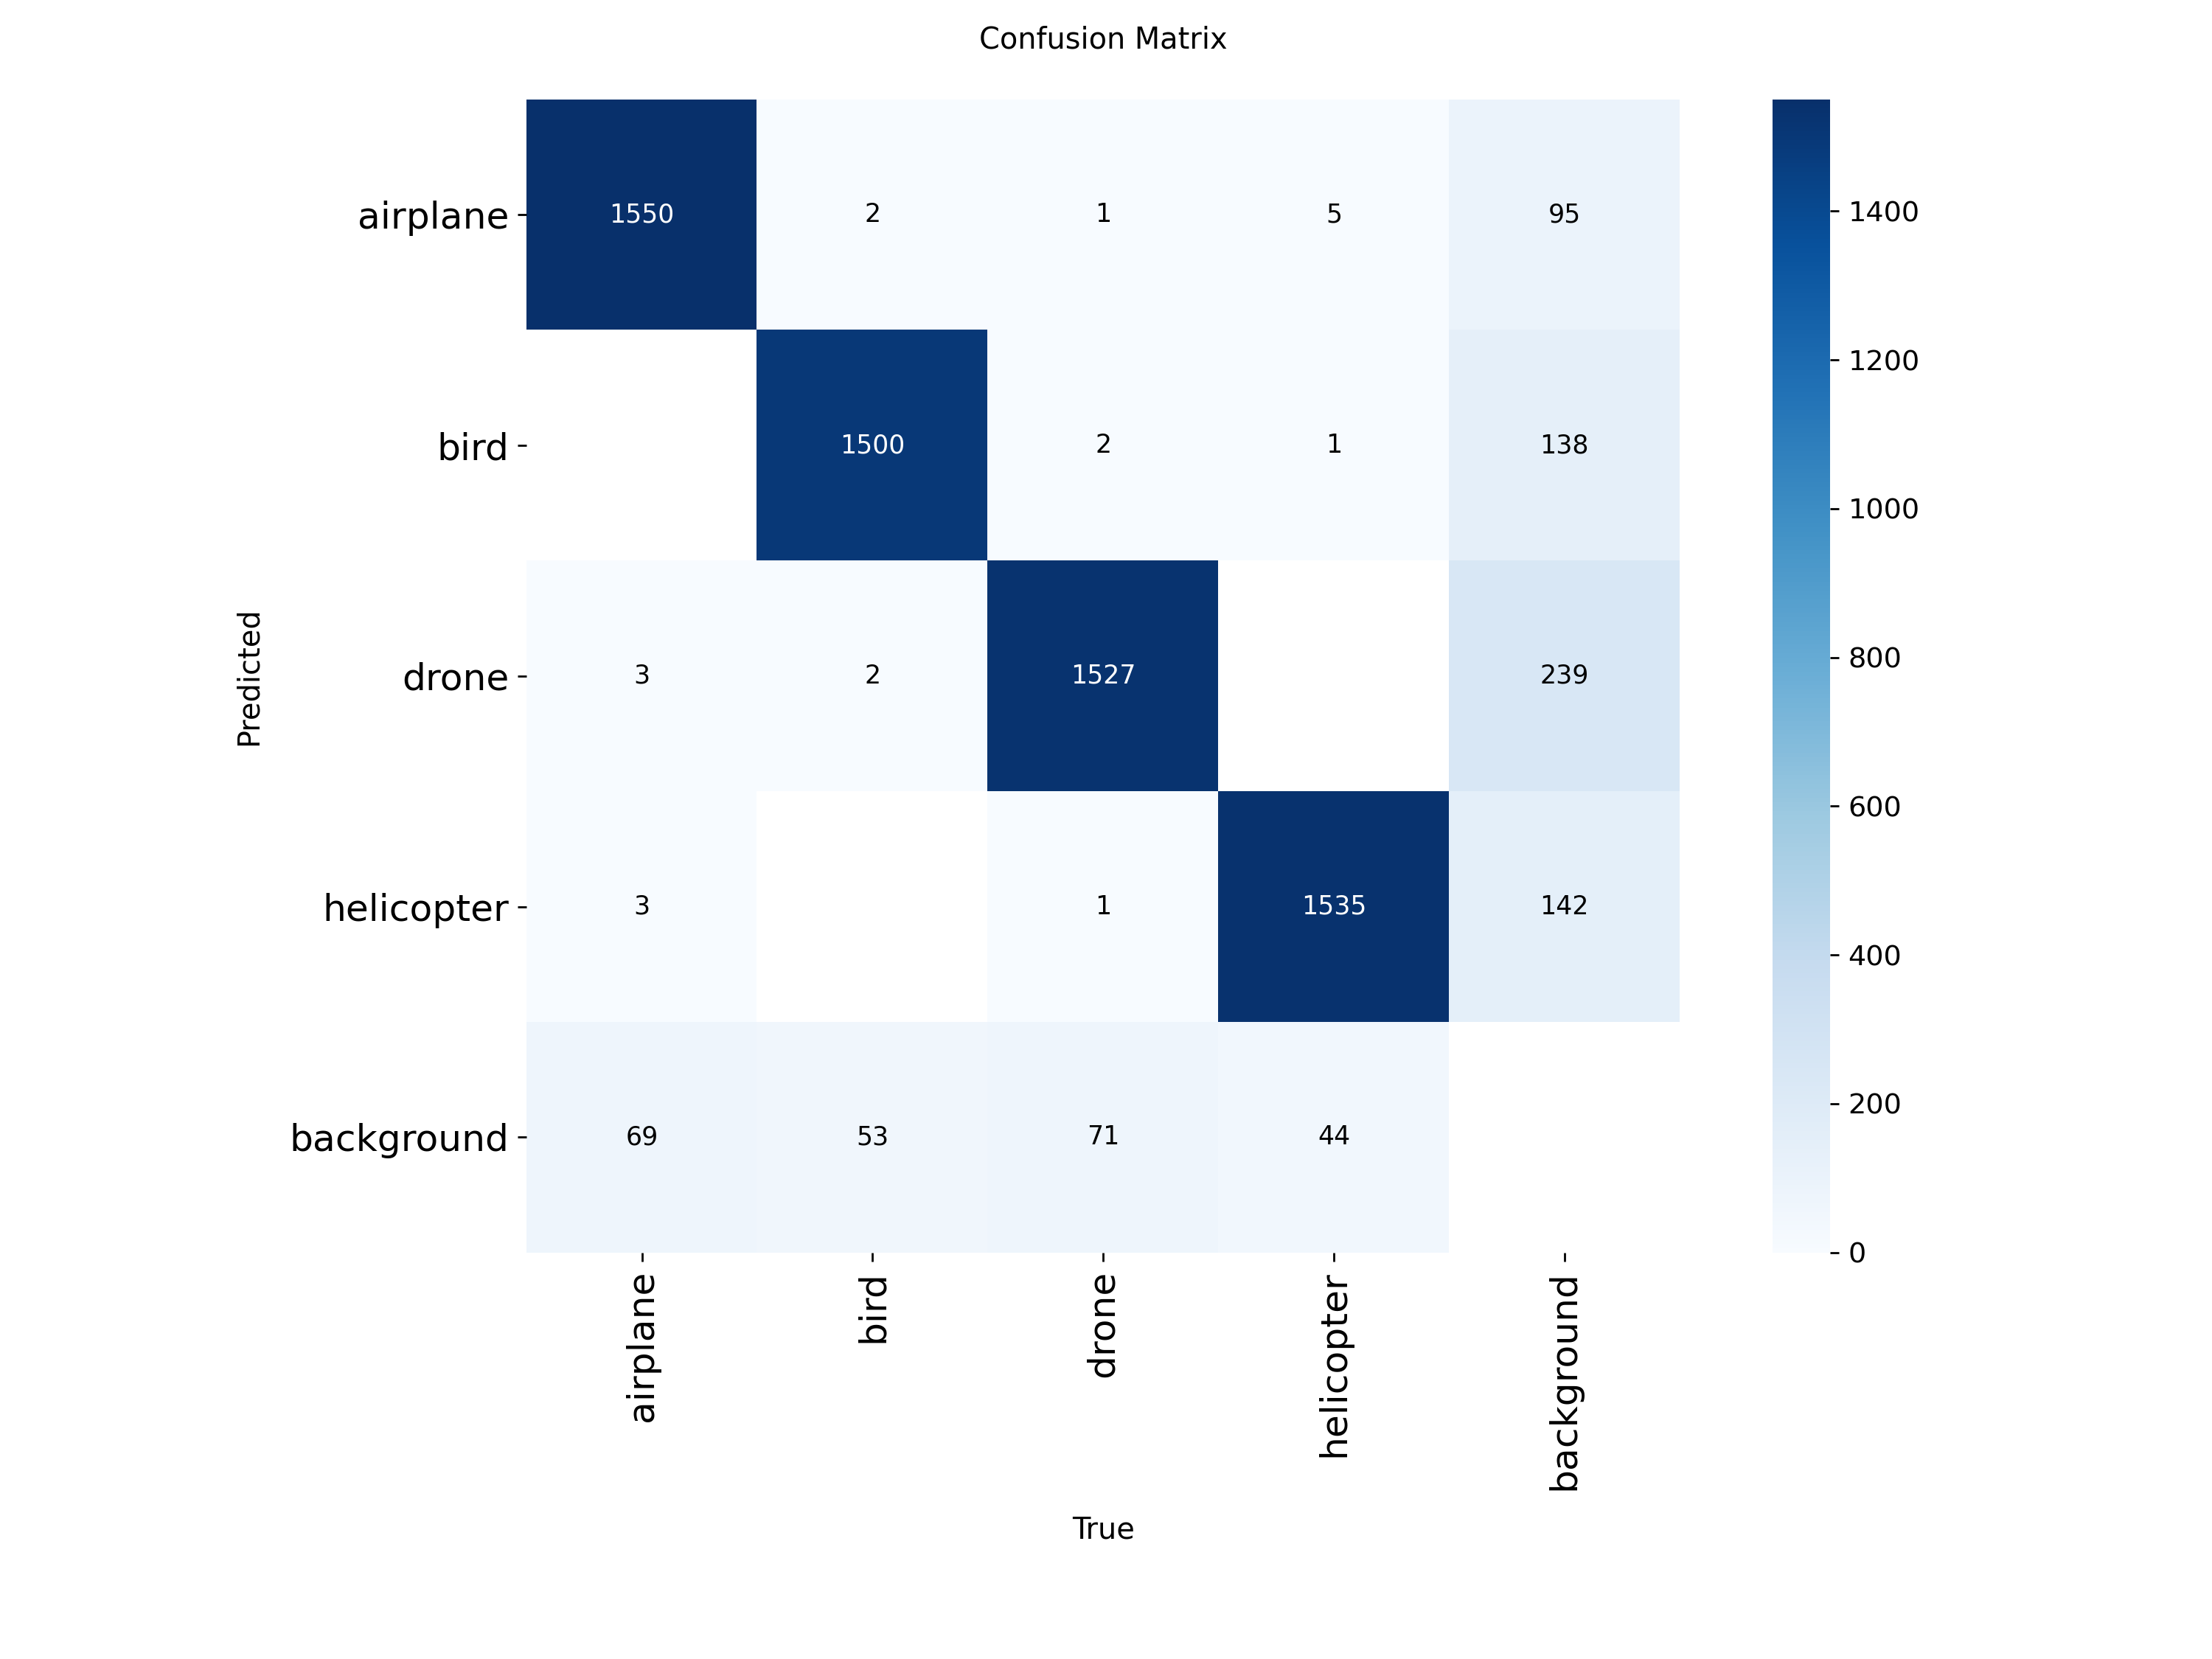


Displaying Precision-Recall Curve:
Precision-Recall curve not found at: /content/runs/detect/val2/PR_curve.png

Displaying Results Plot (Losses and Metrics over Epochs):
Results plot not found at: /content/runs/detect/val2/results.png

--- Model Accuracy Metrics ---
mAP@0.5 (mean Average Precision at 50% IoU): 96.76%
mAP@0.5:0.95 (mean Average Precision across various IoU thresholds): 67.19%
------------------------------


In [ ]:
import os
from IPython.display import Image, display
from ultralytics import YOLO

# Load the best model (if not already loaded)
try:
    model
except NameError:
    model = YOLO("/content/drive/MyDrive/aod4_best_continued.pt")


# Find the latest validation run directory
runs_dir = '/content/runs/detect/'
# Get all entries in runs_dir that are directories and start with 'val'
val_runs = sorted([d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d)) and d.startswith('val')],
                  key=lambda x: int(x.replace('val', '')) if x.replace('val', '').isdigit() else 0)

latest_val_run = val_runs[-1] if val_runs else None

if latest_val_run:
    latest_val_run_path = os.path.join(runs_dir, latest_val_run)
    print(f"Latest validation run directory: {latest_val_run_path}")

    # List some of the key visualization files saved by Ultralytics
    confusion_matrix_path = os.path.join(latest_val_run_path, 'confusion_matrix.png')
    pr_curve_path = os.path.join(latest_val_run_path, 'PR_curve.png')
    results_plot_path = os.path.join(latest_val_run_path, 'results.png')
    # You can also get metrics programmatically if you ran model.val() in a previous cell
    # For simplicity and to show visualizations, we focus on the saved plots here.


    print("\n--- Model Evaluation Visualizations ---")

    print("\nDisplaying Confusion Matrix:")
    if os.path.exists(confusion_matrix_path):
        display(Image(filename=confusion_matrix_path))
    else:
        print(f"Confusion matrix not found at: {confusion_matrix_path}")

    print("\nDisplaying Precision-Recall Curve:")
    if os.path.exists(pr_curve_path):
        display(Image(filename=pr_curve_path))
    else:
        print(f"Precision-Recall curve not found at: {pr_curve_path}")

    print("\nDisplaying Results Plot (Losses and Metrics over Epochs):")
    if os.path.exists(results_plot_path):
        display(Image(filename=results_plot_path))
    else:
        print(f"Results plot not found at: {results_plot_path}")

    # Display key metrics in percentage (assuming model.val() was run previously)
    try:
        if 'metrics' in locals() and metrics is not None:
             print("\n--- Model Accuracy Metrics ---")
             print(f"mAP@0.5 (mean Average Precision at 50% IoU): {metrics.box.map50 * 100:.2f}%")
             print(f"mAP@0.5:0.95 (mean Average Precision across various IoU thresholds): {metrics.box.map * 100:.2f}%")
             # You can add precision and recall here if needed, but mAP is a good overall indicator
             # print(f"Average Precision: {metrics.box.p.mean() * 100:.2f}%")
             # print(f"Average Recall: {metrics.box.r.mean() * 100:.2f}%")
             print("------------------------------")

        else:
            print("\nMetrics object not found. Please run model.val() in a previous cell to see accuracy metrics.")
    except Exception as e:
        print(f"\nAn error occurred while trying to display metrics: {e}")


else:
    print("No validation run directories found starting with 'val'.")